In [89]:
''' quantifying uncertainties in Uranus's shape as a function of those in occultation radii, gravity field, and rotation profile. '''

import matplotlib.pyplot as plt
plt.style.use(f'plots.mplstyle')
%config InlineBackend.figure_format = 'retina'

import numpy as np
from importlib import reload


In [2]:
''' experiment 1: fit r_pol to occultations, first for 'symmetric' (even) wind profile and then for 'composite' (odd) wind profile '''

import mcmc; reload(mcmc)
import wind_profiles; reload(wind_profiles)

# get a callable omega(phi) from observed wind profile, can pass option='symmetric' (default) or option='composite' (an odd profile stitching together Voyager 2 and Keck/Gemini data)
omega = wind_profiles.uranus_omega_tot_interpolant()

# constants for Uranus; French et al. (2024 Icarus) Table 17, Fit 15 (Adopted solution)
r_ref = 25559e5
jn = 3509.291e-6, -35.522e-6, 0.
gm = 5793950.3e15

# create starting position for emcee sampler and check it has finite lnp
ndim = 1
nwalk = 4 * ndim

theta0 = (np.ones(nwalk) + 1e-2 * np.random.rand(nwalk)) * 2.5e9
theta0 = theta0.reshape(nwalk, ndim)
print('starting position:')
print(theta0)

print('starting lnp:')
for iw, theta in enumerate(theta0):
    lnp, blob = mcmc.lnp(theta, jn, r_ref, gm, omega, debug=True)
    assert not np.isinf(lnp), f'got infinite lnp for r_pol guess {theta[0]:.5f}'
    print(lnp)

import emcee
from multiprocessing import Pool

print('sampling:')
# nsteps = 10 # testing
# nsteps = 1000 # slow testing
nsteps = 10000 # production
with Pool() as pool:
    sampler_symmetric = emcee.EnsembleSampler(
        nwalkers=nwalk,
        ndim=ndim,
        log_prob_fn=mcmc.lnp,
        pool=pool, # comment out to do it serially. using multiprocessing.Pool is giving me ~37 it/s compared to ~22 it/s serially
        args=(jn, r_ref, gm, omega),
        kwargs={'debug':True,}
    )

    sampler_symmetric.run_mcmc(
        initial_state=theta0,
        nsteps=nsteps,
        progress=True,
    )

starting position:
[[2.50168700e+09]
 [2.50816390e+09]
 [2.51509607e+09]
 [2.51545932e+09]]
starting lnp:
-107.23430765278923
-586.1331252833106
-1524.792734463605
-1586.1421738144209
sampling:


100%|██████████| 10000/10000 [04:40<00:00, 35.68it/s]


symmetric: 24968.5 +/- 3.3 km


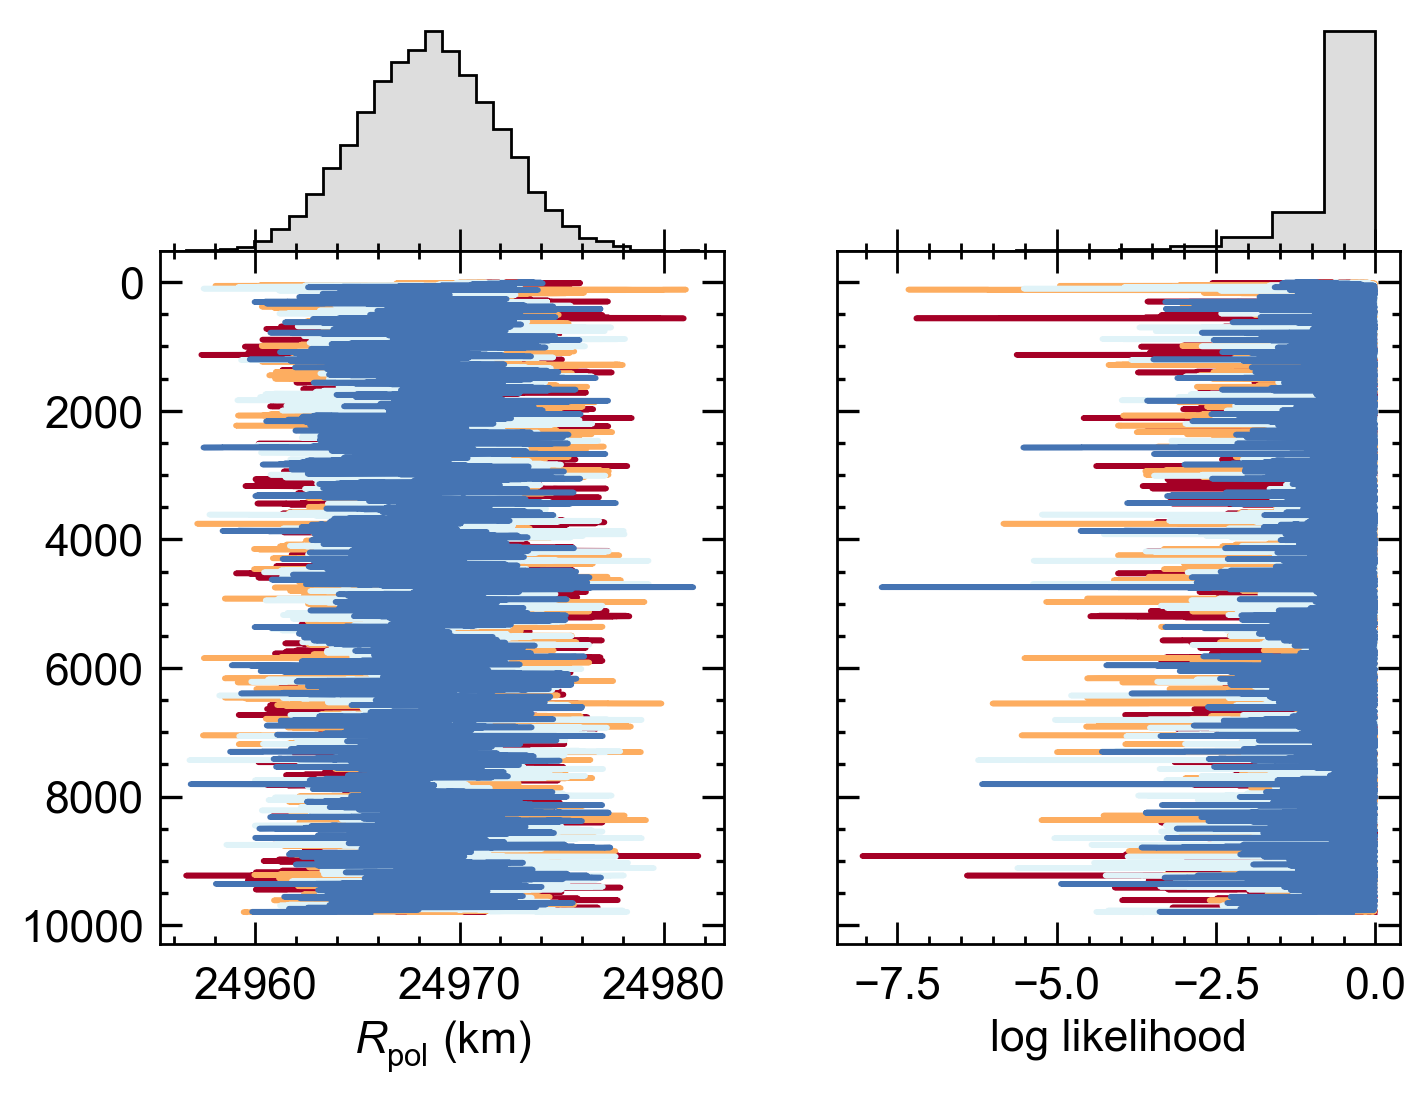

In [3]:
nstep, nwalk, ndim = sampler_symmetric.get_chain().shape
fig, ax = plt.subplots(2, ndim + 1, figsize=(4 * (ndim + 1), 6), gridspec_kw={'hspace':0, 'height_ratios':(1, 3)})

nburn = 200
for idim in range(ndim):
    f = 1e-5 if idim == 0 else 1
    for iw, w in enumerate(sampler_symmetric.get_chain()[nburn:, :, idim].T):
        ax[1, idim].plot(f * w, np.arange(len(w)), color=plt.get_cmap('RdYlBu')(0.9 * iw / (nwalk - 1)))
    ax[1, idim].set_ylim(*ax[1, idim].get_ylim()[::-1])
    ax[0, idim].hist(sampler_symmetric.get_chain()[nburn:, :, idim].flatten(), bins=30, histtype='stepfilled', edgecolor='k', facecolor='#dddddd')

for iw, w in enumerate(sampler_symmetric.get_log_prob()[nburn:].T):
    ax[1, -1].plot(w, np.arange(len(w)), color=plt.get_cmap('RdYlBu')(0.9 * iw / (nwalk - 1)))
ax[0, -1].hist(sampler_symmetric.get_log_prob()[nburn:].flatten(), histtype='stepfilled', edgecolor='k', facecolor='#dddddd')
ax[1, -1].set_ylim(*ax[1, -1].get_ylim()[::-1])

[z.tick_params(labelbottom=False, labelleft=False, left=False, top=False, right=False, which='both') for z in ax[0]]
[z.tick_params(labelleft=False) for z in ax[1, 1:]]
[z.spines[['left', 'right', 'top']].set_visible(False) for z in ax[0]]

ax[-1, 0].set_xlabel(r'$R_{\rm pol}\ ({\rm km})$')
ax[-1, -1].set_xlabel('log likelihood')

rp = sampler_symmetric.get_chain()[nburn:, :, 0].flatten()
print(f'symmetric: {np.mean(1e-5 * rp):.1f} +/- {np.std(1e-5 * rp):.1f} km')

In [4]:
omega_composite = wind_profiles.uranus_omega_tot_interpolant('composite') # north-south asymmetric wind

# create starting position for emcee sampler and check it has finite lnp
ndim = 1
nwalk = 4 * ndim

theta0 = (np.ones(nwalk) + 1e-2 * np.random.rand(nwalk)) * 2.5e9
theta0 = theta0.reshape(nwalk, ndim)
print('starting position:')
print(theta0)

print('starting lnp:')
for iw, theta in enumerate(theta0):
    lnp, blob = mcmc.lnp(theta, jn, r_ref, gm, omega_composite, debug=True)
    assert not np.isinf(lnp), f'got infinite lnp for r_pol guess {theta[0]:.5f}'
    print(lnp)

import emcee
from multiprocessing import Pool

print('sampling:')
# nsteps = 10
# nsteps = 1000
nsteps = 10000
with Pool() as pool:
    sampler_composite = emcee.EnsembleSampler(
        nwalkers=nwalk,
        ndim=ndim,
        log_prob_fn=mcmc.lnp,
        pool=pool, # this wind profile is slower, ~13 it/s using multiprocessing.Pool
        args=(jn, r_ref, gm, omega_composite),
        kwargs={'debug':True,}
    )

    sampler_composite.run_mcmc(
        initial_state=theta0,
        nsteps=nsteps,
        progress=True,
    )

starting position:
[[2.50606394e+09]
 [2.50166322e+09]
 [2.50939100e+09]
 [2.50021628e+09]]
starting lnp:
-379.4891018249939
-101.39800668230593
-707.4581429803386
-48.66983967480007
sampling:


100%|██████████| 10000/10000 [12:53<00:00, 12.93it/s]


symmetric: 24969.4 +/- 3.3 km


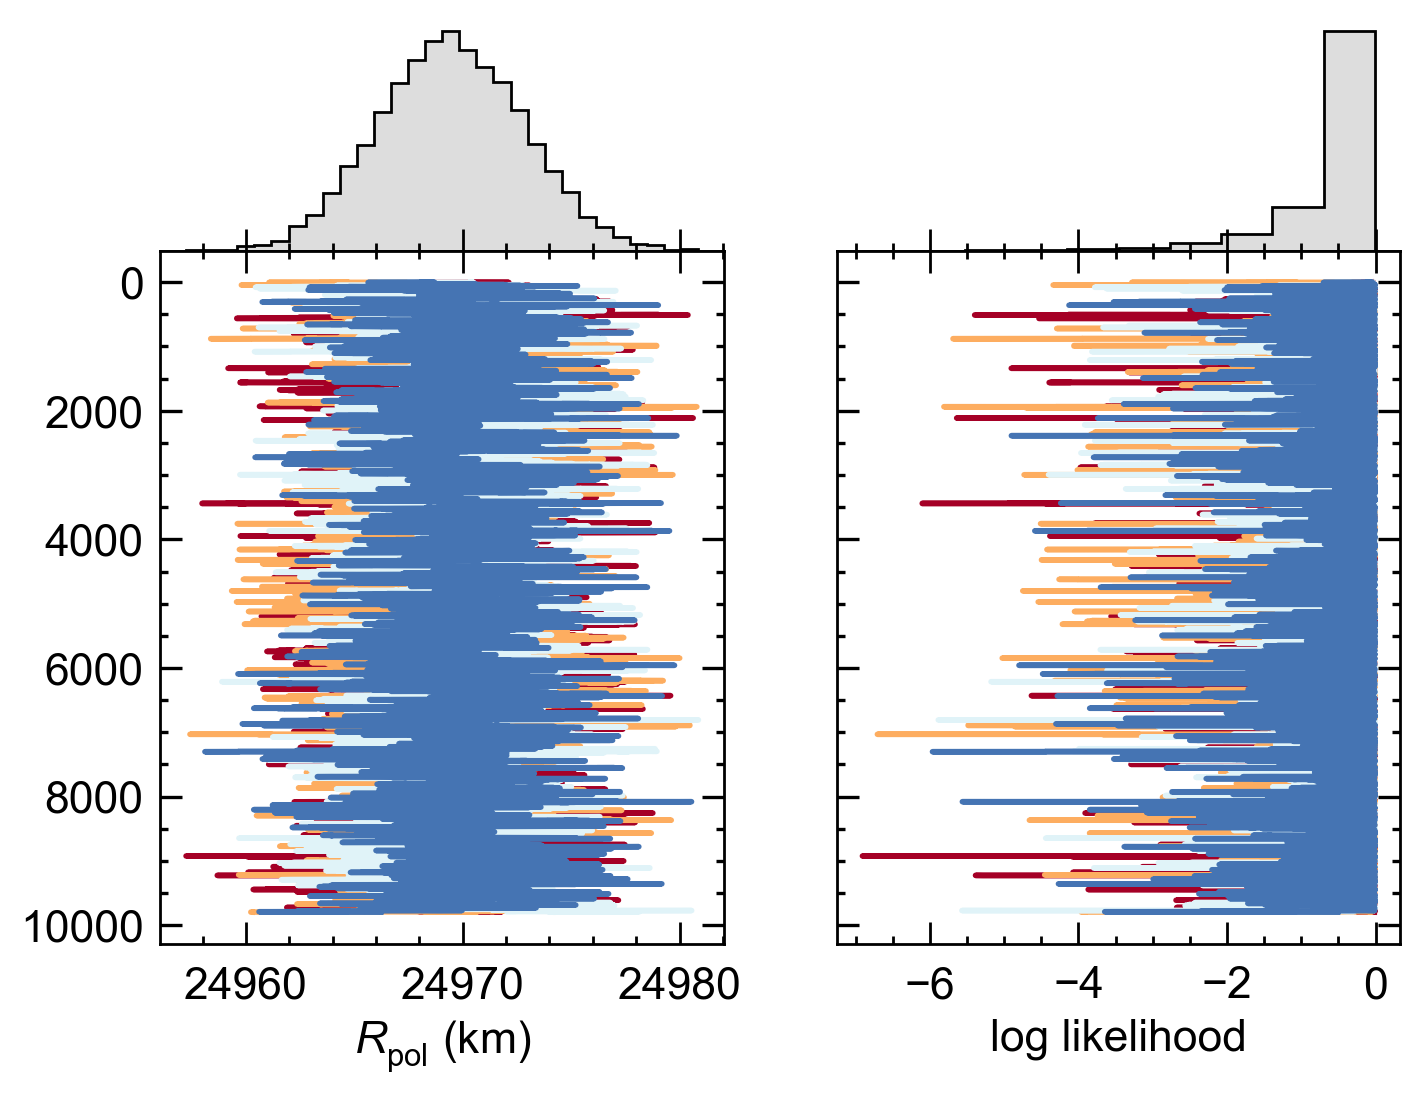

In [33]:
nstep, nwalk, ndim = sampler_composite.get_chain().shape
fig, ax = plt.subplots(2, ndim + 1, figsize=(4 * (ndim + 1), 6), gridspec_kw={'hspace':0, 'height_ratios':(1, 3)})

nburn = 200
for idim in range(ndim):
    f = 1e-5 if idim == 0 else 1
    for iw, w in enumerate(sampler_composite.get_chain()[nburn:, :, idim].T):
        ax[1, idim].plot(f * w, np.arange(len(w)), color=plt.get_cmap('RdYlBu')(0.9 * iw / (nwalk - 1)))
    ax[1, idim].set_ylim(*ax[1, idim].get_ylim()[::-1])
    ax[0, idim].hist(sampler_composite.get_chain()[nburn:, :, idim].flatten(), bins=30, histtype='stepfilled', edgecolor='k', facecolor='#dddddd')

for iw, w in enumerate(sampler_composite.get_log_prob()[nburn:].T):
    ax[1, -1].plot(w, np.arange(len(w)), color=plt.get_cmap('RdYlBu')(0.9 * iw / (nwalk - 1)))
ax[0, -1].hist(sampler_composite.get_log_prob()[nburn:].flatten(), histtype='stepfilled', edgecolor='k', facecolor='#dddddd')
ax[1, -1].set_ylim(*ax[1, -1].get_ylim()[::-1])

[z.tick_params(labelbottom=False, labelleft=False, left=False, top=False, right=False, which='both') for z in ax[0]]
[z.tick_params(labelleft=False) for z in ax[1, 1:]]
[z.spines[['left', 'right', 'top']].set_visible(False) for z in ax[0]]

ax[-1, 0].set_xlabel(r'$R_{\rm pol}\ ({\rm km})$')
ax[-1, -1].set_xlabel('log likelihood')

rp = sampler_composite.get_chain()[nburn:, :, 0].flatten()
print(f'symmetric: {np.mean(1e-5 * rp):.1f} +/- {np.std(1e-5 * rp):.1f} km')

starting position:
[[ 2.51651129e+09  3.50929234e-03 -3.55220805e-05]
 [ 2.51885576e+09  3.50929188e-03 -3.55220763e-05]
 [ 2.50621371e+09  3.50929254e-03 -3.55220322e-05]
 [ 2.50817094e+09  3.50929575e-03 -3.55220557e-05]
 [ 2.51151897e+09  3.50929126e-03 -3.55220458e-05]
 [ 2.51277605e+09  3.50929339e-03 -3.55220003e-05]]
starting lnp:
-1770.649184444905
-2218.447118316799
-401.50583183778605
-586.8671743112145
-985.3643777413854
-1161.5457578977932
sampling:


100%|██████████| 10000/10000 [04:37<00:00, 36.02it/s]


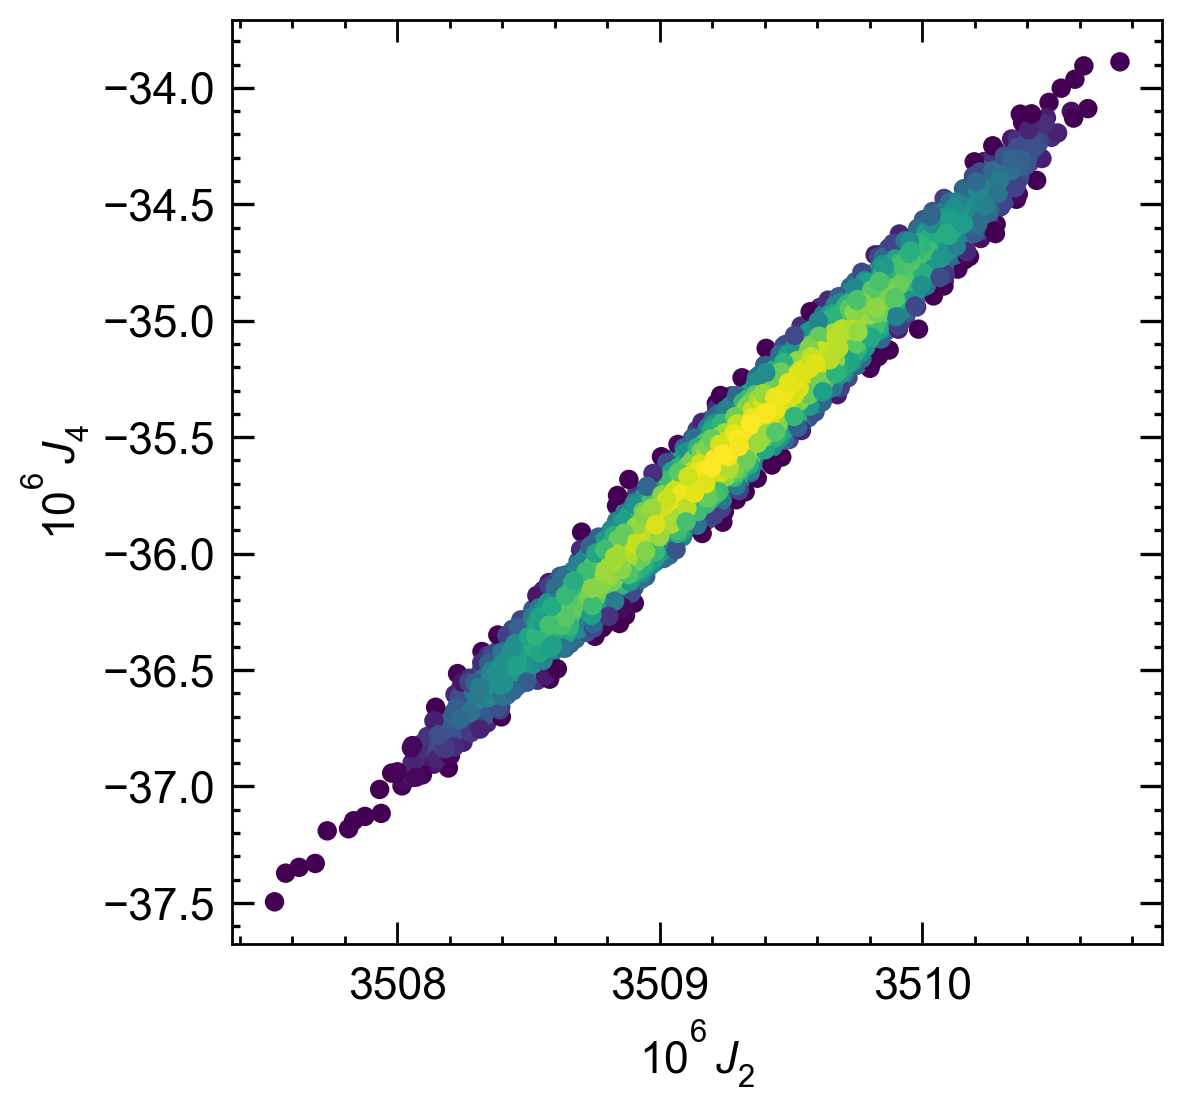

In [ ]:
''' experiment 2: vary r_pol, j2, j4 '''

# show j2-j4 prior distribution
x = mcmc.gauss_jn_uranus.rvs(10000)
lnp = mcmc.gauss_jn_uranus.logpdf(x) - mcmc.gauss_jn_uranus.logpdf(mcmc.gauss_jn_uranus.mean)
plt.scatter(1e6 * x[:, 0], 1e6 * x[:, 1], c=lnp, vmin=-5)
plt.xlabel(r'$10^6\,J_2$')
plt.ylabel(r'$10^6\,J_4$')

omega = wind_profiles.uranus_omega_tot_interpolant()

# create starting position for emcee sampler and check it has finite lnp
ndim = 3
nwalk = 2 * ndim

theta0 = np.zeros((nwalk, ndim))
theta0[:, 0] = 2.5e9 * (1. + np.random.rand(nwalk) * 1e-2) # r_pol # 1% spread around arbitrary starting guess
theta0[:, 1] = mcmc.gauss_jn_uranus.mean[0] * (1. + np.random.rand(nwalk) * mcmc.gauss_jn_uranus.cov[0, 0] ** 0.5 * 5) # j2 # uniform 5-sigma spread around measurement 
theta0[:, 2] = mcmc.gauss_jn_uranus.mean[1] * (1. + np.random.rand(nwalk) * mcmc.gauss_jn_uranus.cov[1, 1] ** 0.5 * 5) # j4 # uniform 5-sigma spread around measurement
print('starting position:')
print(theta0)

print('starting lnp:')
for iw, theta in enumerate(theta0):
    # lnp, blob = mcmc.lnp_prior_vary_jn(theta, r_ref, gm, omega, debug=True)
    lnp, blob = mcmc.lnp_vary_jn(theta, r_ref, gm, omega, debug=True) # note jn are only passed as elements of theta: varied from model to model
    assert not np.isinf(lnp), f'got infinite lnp for r_pol guess {theta[0]:.5f}'
    print(lnp)

import emcee
from multiprocessing import Pool

print('sampling:')
# nsteps = 10
# nsteps = 1000
nsteps = 10000
with Pool() as pool:
    sampler_jn = emcee.EnsembleSampler(
        nwalkers=nwalk,
        ndim=ndim,
        log_prob_fn=mcmc.lnp_vary_jn,
        pool=pool, # comment out to do it serially. using multiprocessing.Pool is giving me ~37 it/s compared to ~22 it/s serially
        args=(r_ref, gm, omega),
        # kwargs={'debug':True,}
        kwargs={'debug':False,'sigma_rocc_km':0.05} # make the RO uncertainty near-negligible at 50 meters to isolate the effect of the uncertain gravity field
    )

    sampler_jn.run_mcmc(
        initial_state=theta0,
        nsteps=nsteps,
        progress=True,
    )

vary jn: 24968.435 +/- 0.042 km


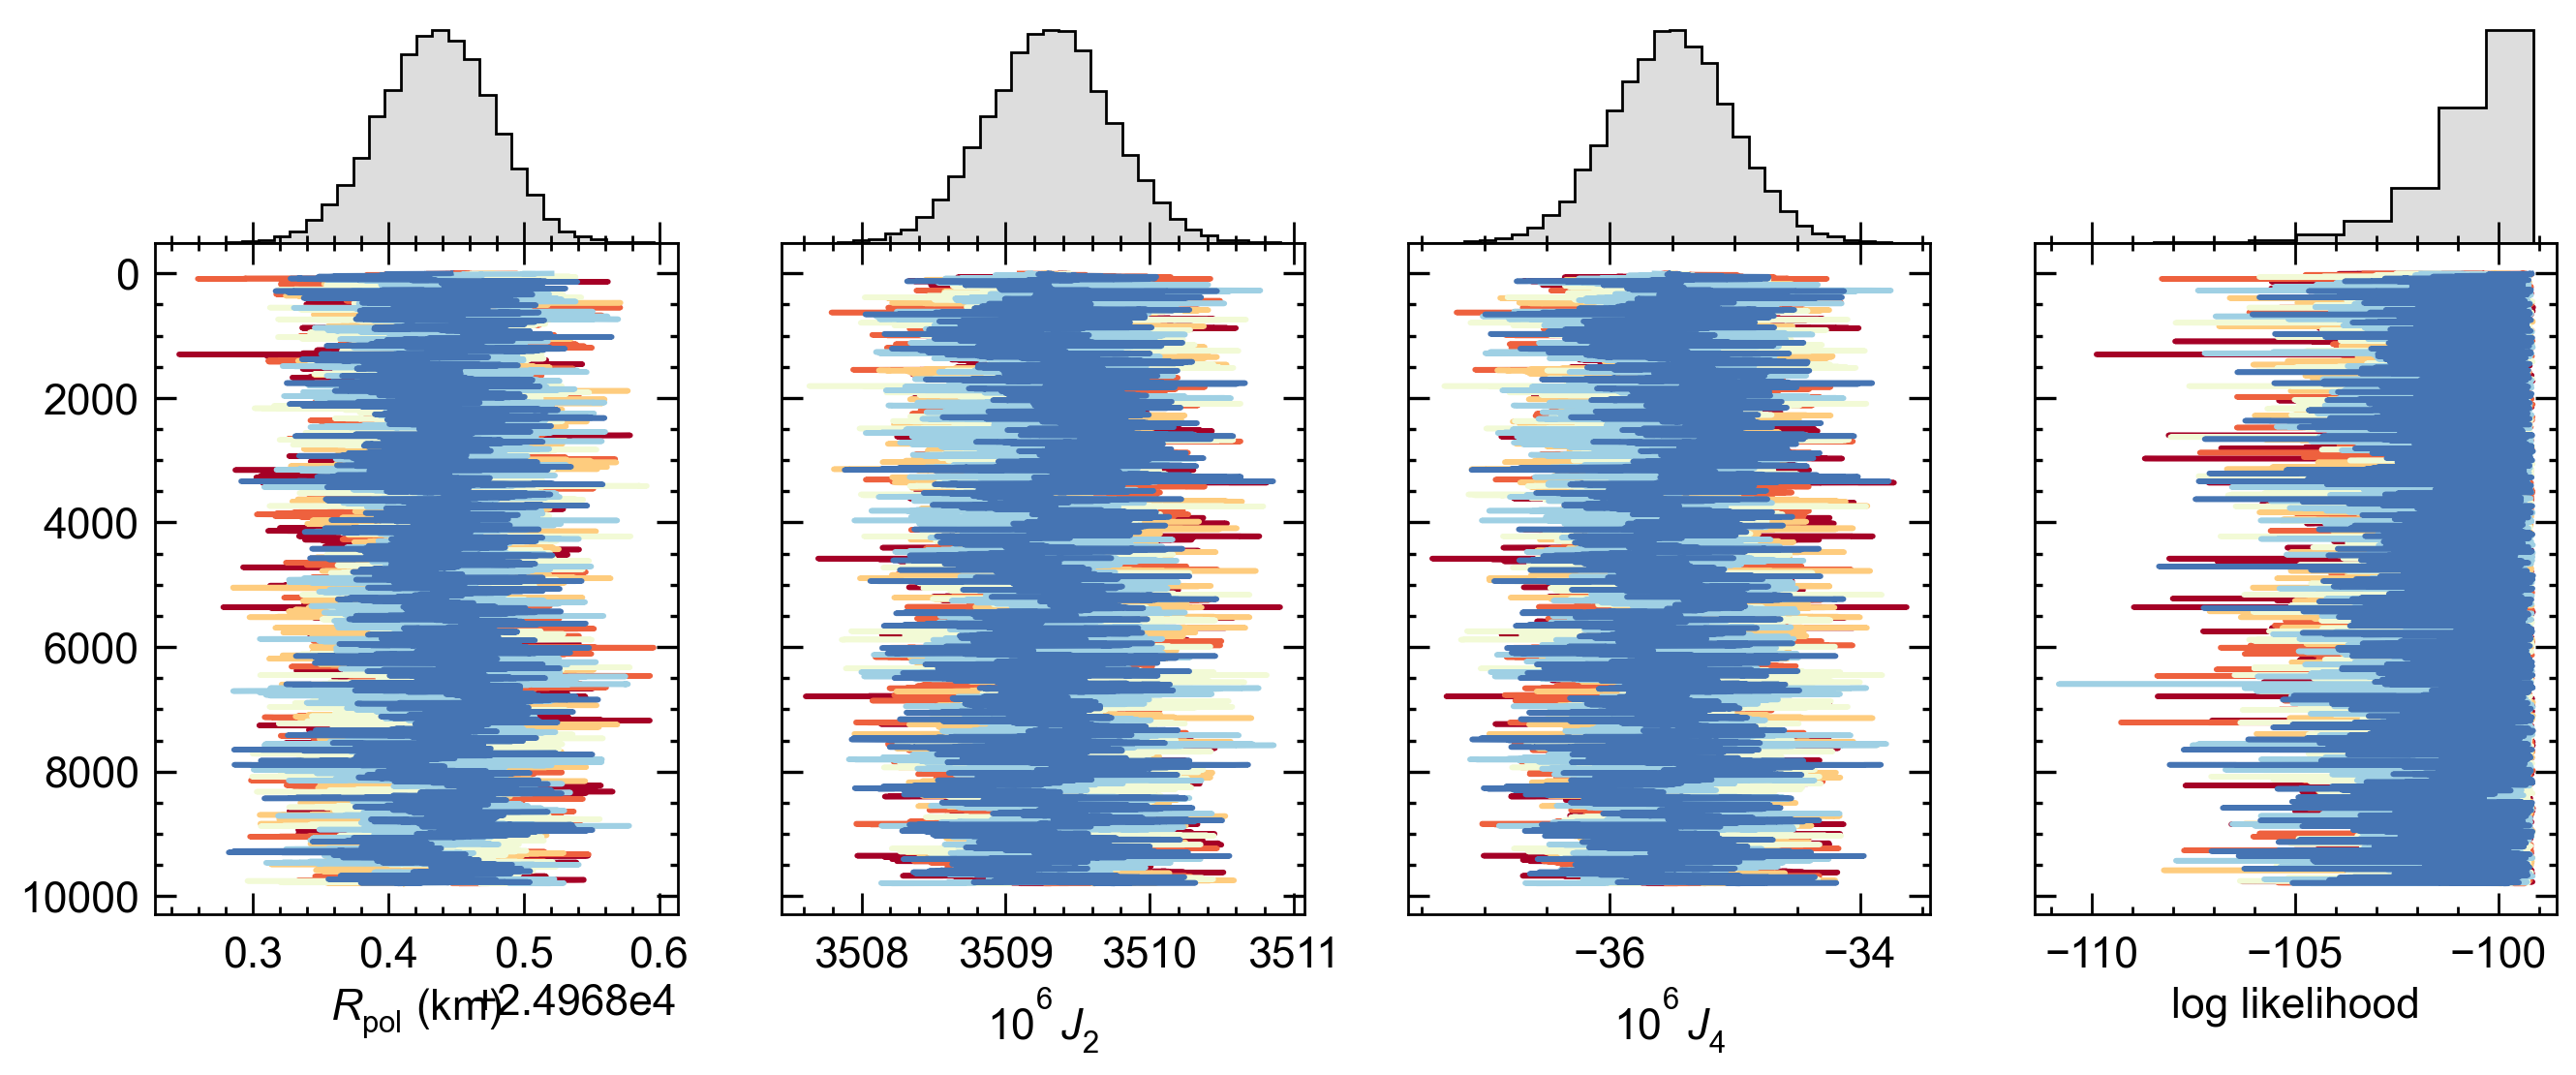

In [35]:
nstep, nwalk, ndim = sampler_jn.get_chain().shape
fig, ax = plt.subplots(2, ndim + 1, figsize=(4 * (ndim + 1), 6), gridspec_kw={'hspace':0, 'height_ratios':(1, 3)})

nburn = 200
for idim in range(ndim):
    f = {0:1e-5, 1:1e6, 2:1e6, 3:1}[idim]
    for iw, w in enumerate(sampler_jn.get_chain()[nburn:, :, idim].T):
        ax[1, idim].plot(f * w, np.arange(len(w)), color=plt.get_cmap('RdYlBu')(0.9 * iw / (nwalk - 1)))
    ax[1, idim].set_ylim(*ax[1, idim].get_ylim()[::-1])
    ax[0, idim].hist(sampler_jn.get_chain()[nburn:, :, idim].flatten(), bins=30, histtype='stepfilled', edgecolor='k', facecolor='#dddddd')

for iw, w in enumerate(sampler_jn.get_log_prob()[nburn:].T):
    ax[1, -1].plot(w, np.arange(len(w)), color=plt.get_cmap('RdYlBu')(0.9 * iw / (nwalk - 1)))
ax[0, -1].hist(sampler_jn.get_log_prob()[nburn:].flatten(), histtype='stepfilled', edgecolor='k', facecolor='#dddddd')
ax[1, -1].set_ylim(*ax[1, -1].get_ylim()[::-1])

[z.tick_params(labelbottom=False, labelleft=False, left=False, top=False, right=False, which='both') for z in ax[0]]
[z.tick_params(labelleft=False) for z in ax[1, 1:]]
[z.spines[['left', 'right', 'top']].set_visible(False) for z in ax[0]]

ax[-1, 0].set_xlabel(r'$R_{\rm pol}\ ({\rm km})$')
ax[-1, 1].set_xlabel(r'$10^6\,J_2$')
ax[-1, 2].set_xlabel(r'$10^6\,J_4$')
ax[-1, 3].set_xlabel('log likelihood')

rp = sampler_jn.get_chain()[nburn:, :, 0].flatten()
print(f'vary jn: {np.mean(1e-5 * rp):.3f} +/- {np.std(1e-5 * rp):.3f} km')

In [ ]:
# the above mcmc sample varying j2, j4 required a nonzero (50-m) uncertainty on occultation radii to perform well in terms of statistical convergence.
# hence, the ~50-m standard deviation in the r_pol posterior distribution is not really representative of the (tiny) influence of jn, but just reflects the occultation erro we imposed a priori.
# here do the much simpler exercise of starting at the closest occultation point to equator (or pole), randomly drawing j2 and j4 from their Gaussian ellipse, and integrating Equation 3 to equator (or pole).

def sample_jn(nsteps=10000):
    import mcmc; reload(mcmc)
    import wind_profiles; reload(wind_profiles)
    import geoid
    from occultation_data import uranus as occultation_radii

    # get a callable omega(phi) from observed wind profile, can pass option='symmetric' (default) or option='composite' (an odd profile stitching together Voyager 2 and Keck/Gemini data)
    omega = wind_profiles.uranus_omega_tot_interpolant()

    # constants for Uranus; French et al. (2024 Icarus) Table 17, Fit 15 (Adopted solution)
    r_ref = 25559e5
    jn = 3509.291e-6, -35.522e-6, 0.
    gm = 5793950.3e15

    from scipy.stats import norm
    gauss_j6 = norm(loc=1e-6, scale=1e-6)

    g = geoid.geoid(24968.4e5, jn, r_ref, gm, omega=omega) # create geoid object just for its grid
    def _dr_dphi(phi, r, jn): # adapted from geoid.geoid
        return r * geoid.gphi_(r, np.sin(phi), *jn, r_ref, gm, omega(phi)) / geoid.gr_(r, np.sin(phi), *jn, r_ref, gm, omega(phi))

    from scipy.integrate import solve_ivp

    re = np.zeros(nsteps)
    rp = np.zeros(nsteps)
    from tqdm import tqdm
    j2 = np.zeros(nsteps)
    j4 = np.zeros(nsteps)
    j6 = np.zeros(nsteps)
    for i, _jn in tqdm(enumerate(mcmc.gauss_jn_uranus.rvs(nsteps))):

        # on top of observed j2-j4, consider j6 = 0 +/- 1e-6
        jn = (*_jn, gauss_j6.rvs()) # tuple of j2, j4, j6

        # integrate from voyager 2 ingress (-2.9 deg S) to equator
        lat, rocc = occultation_radii['voyager 2 ingress']
        re[i] = solve_ivp(_dr_dphi, np.array([lat * np.pi / 180, 0.]), np.array([rocc*1e5]), args=(jn,), t_eval=np.array([0.]), rtol=1e-8, atol=1e-8).y[0, 0]

        # integrate from voyager 2 egress (-6.6 deg S) to south pole
        lat, rocc = occultation_radii['voyager 2 egress']
        rp[i] = solve_ivp(_dr_dphi, np.array([lat * np.pi / 180, -np.pi/2]), np.array([rocc*1e5]), args=(jn,), t_eval=np.array([-np.pi/2]), rtol=1e-8, atol=1e-8).y[0, 0]

        j2[i], j4[i], j6[i] = jn

    # note, means are close but will not agree perfectly with baseline models, since only one occultation is being fit at a time
    print(1e-5 * np.mean(rp), 1e-5 * np.std(rp))
    print(1e-5 * np.mean(re), 1e-5 * np.std(re))

    return {'rp':rp, 're':re, 'j2':j2, 'j4':j4, 'j6':j6}

results_sample_jn = sample_jn()

# vary just j2, j4:
# 10000it [00:28, 352.36it/s]
# 24968.902301245846 0.024855275442808827
# 25556.619927898206 7.65908600921989e-05

# add in j6 = 1e-6 +/- 1e-6:
# 10000it [00:28, 345.91it/s]
# 24968.867392900604 0.04322191014794759
# 25556.620350943573 0.00044854831549961607


10000it [00:28, 345.91it/s]

24968.867392900604 0.04322191014794759
25556.620350943573 0.00044854831549961607


In [8]:
''' experiment 3: vary r_pol and Legendre coefficients in Sromovsky+ 2015 symmetric wind profile fit '''

import mcmc; reload(mcmc)
import wind_profiles; reload(wind_profiles)

# constants for Uranus; French et al. (2024 Icarus) Table 17, Fit 15 (Adopted solution)
r_ref = 25559e5
jn = 3509.291e-6, -35.522e-6, 0.
gm = 5793950.3e15

# create starting position for emcee sampler and check it has finite lnp
ndim = 1 + 10 # 10 params are for even Legendre coefficients between 0 and 18, per S15
nwalk = 2 * ndim

theta0 = np.zeros((nwalk, ndim))
theta0[:, 0] = 2.5e9 * (1. + np.random.rand(nwalk) * 1e-2) # r_pol # 1% spread around arbitrary starting guess
theta0[:, 1:] = mcmc.gauss_cn.rvs(nwalk) # draw wind fit coefficients from the Gaussian prior
# print('starting position:')
# print(theta0)

# print('starting lnp:')
for iw, theta in enumerate(theta0):
    lnp, blob = mcmc.lnp_vary_wind(theta, jn, r_ref, gm, debug=True)
    assert not np.isinf(lnp), f'got infinite lnp for r_pol guess {theta[0]*1e-9:.5f}'

import emcee
from multiprocessing import Pool

print('sampling:')
# nsteps = 10
# nsteps = 1000
nsteps = 10000
with Pool() as pool:
    sampler_wind = emcee.EnsembleSampler(
        nwalkers=nwalk,
        ndim=ndim,
        log_prob_fn=mcmc.lnp_vary_wind,
        pool=pool, # comment out to do it serially. using multiprocessing.Pool is giving me ~37 it/s compared to ~22 it/s serially
        args=(jn, r_ref, gm),
        kwargs={'debug':False,'sigma_rocc_km':0.05} # make the RO uncertainty near-negligible at 50 meters to isolate the effect of uncertain winds
    )

    sampler_wind.run_mcmc(
        initial_state=theta0,
        nsteps=nsteps,
        progress=True,
    )


sampling:


100%|██████████| 10000/10000 [1:44:28<00:00,  1.60it/s]    


vary wind: 24968.5 +/- 0.4 km


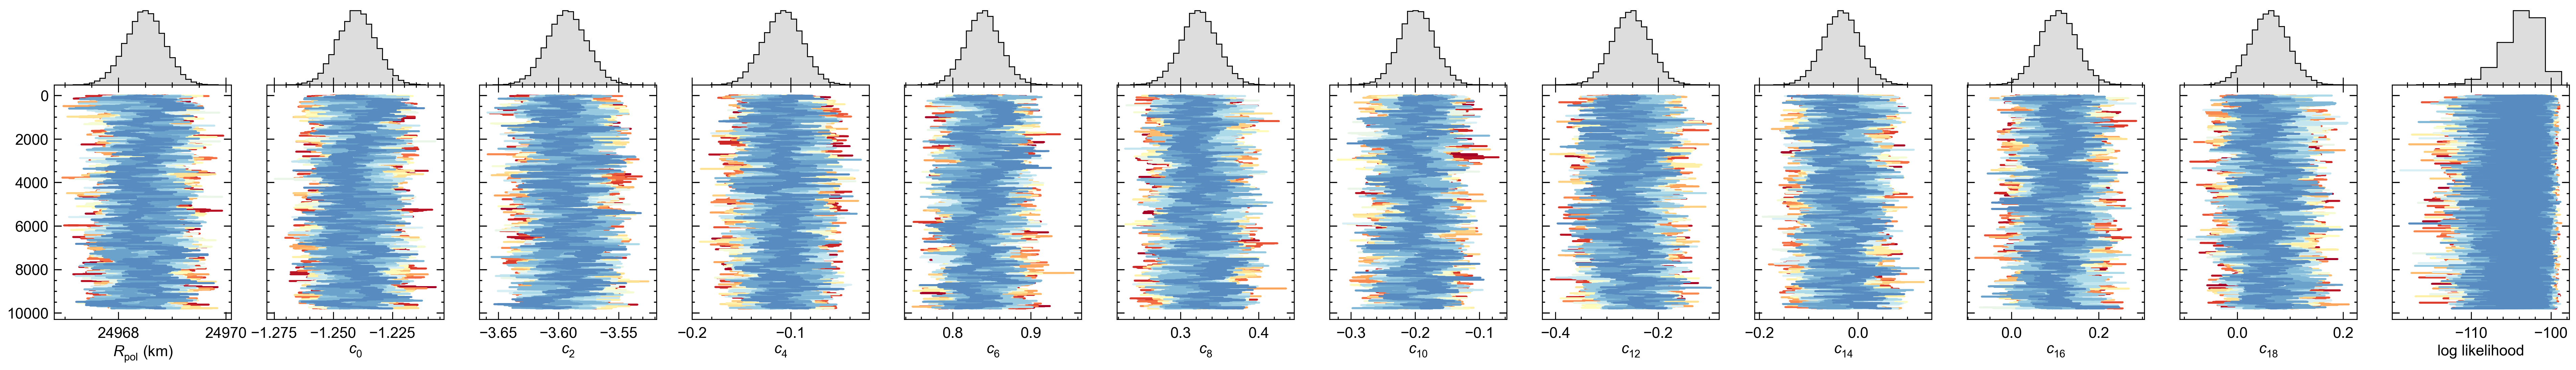

In [9]:
nstep, nwalk, ndim = sampler_wind.get_chain().shape
nburn = 200
# nburn = 0
fig, ax = plt.subplots(2, ndim + 1, figsize=(4 * (ndim + 1), 6), gridspec_kw={'hspace':0, 'height_ratios':(1, 3)})

for idim in range(ndim):
    f = 1e-5 if idim == 0 else 1
    for iw, w in enumerate(sampler_wind.get_chain()[nburn:, :, idim].T):
        ax[1, idim].plot(f * w, np.arange(len(w)), color=plt.get_cmap('RdYlBu')(0.9 * iw / nwalk))
    ax[1, idim].set_ylim(*ax[1, idim].get_ylim()[::-1])
    ax[0, idim].hist(sampler_wind.get_chain()[nburn:, :, idim].flatten(), bins=30, histtype='stepfilled', edgecolor='k', facecolor='#dddddd')

for iw, w in enumerate(sampler_wind.get_log_prob()[nburn:].T):
    ax[1, -1].plot(w, np.arange(len(w)), color=plt.get_cmap('RdYlBu')(0.9 * iw / nwalk))
ax[1, -1].set_ylim(*ax[1, -1].get_ylim()[::-1])
ax[0, -1].hist(sampler_wind.get_log_prob()[nburn:].flatten(), histtype='stepfilled', edgecolor='k', facecolor='#dddddd')

[z.tick_params(labelbottom=False, labelleft=False, left=False, top=False, right=False, which='both') for z in ax[0]]
[z.tick_params(labelleft=False) for z in ax[1, 1:]]
[z.spines[['left', 'right', 'top']].set_visible(False) for z in ax[0]]

ax[-1, 0].set_xlabel(r'$R_{\rm pol}\ ({\rm km})$')
ax[-1, -1].set_xlabel('log likelihood')
[ax[-1, 1+i].set_xlabel(f'$c_{{{2*i}}}$') for i in range(10)]

rp = sampler_wind.get_chain()[nburn:, :, 0].flatten()
print(f'vary wind: {np.mean(1e-5 * rp):.1f} +/- {np.std(1e-5 * rp):.1f} km')

symmetric profile: $24968.5\pm0.4$ km


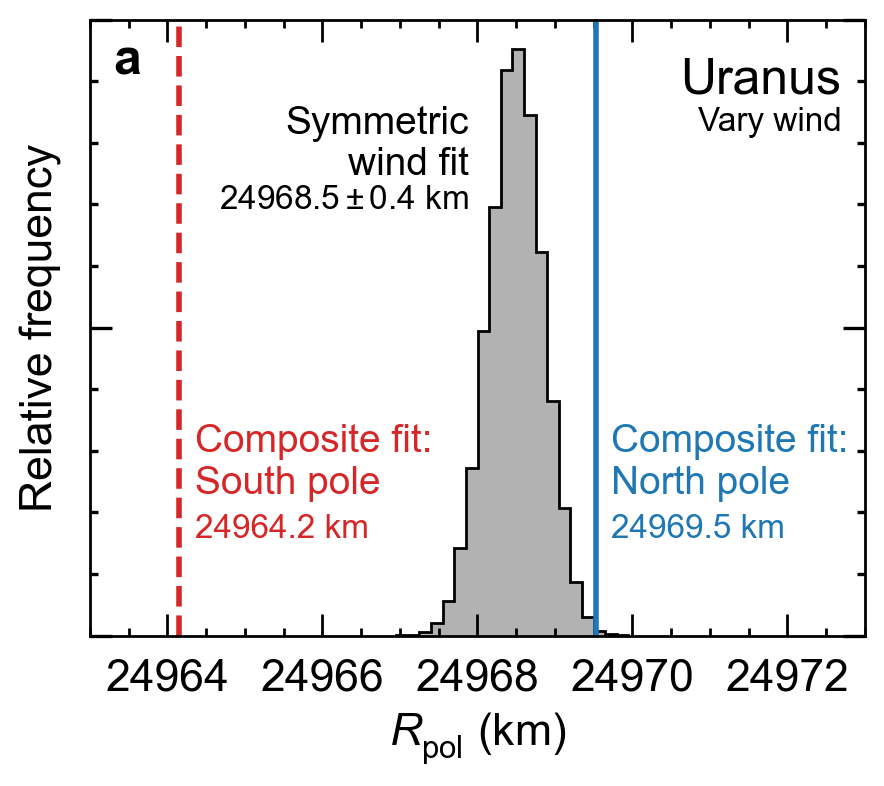

In [5]:
nburn = 200
plt.figure(figsize=(5, 4))

# rp = np.array([g.r[0] for seed, g in models_vary_wind['symmetric'].items()])
rp = np.array([g.r[0] for g in sampler_wind.get_blobs()[nburn:].flatten()])
plt.hist(1e-5 * rp, alpha=0.3, density=True, color='k', bins=20, histtype='stepfilled')
plt.hist(1e-5 * rp, density=True, color='k', bins=20, histtype='step')

stats = rf'${np.mean(rp*1e-5):.1f}\pm{np.std(rp*1e-5):.1f}$ km'
print('symmetric profile:', stats)
plt.text(np.mean(rp*1e-5) - 0.6, 1., 'Symmetric\nwind fit', ha='right', va='top', color='k', fontsize=14)
plt.text(np.mean(rp*1e-5) - 0.6, 0.85, stats, ha='right', va='top', color='k', fontsize=12)

yl = np.array(plt.ylim())
# yl[1] *= 1.2

# for comparison, take best model from the composite fit
ibest_composite = np.argmax(sampler_composite.get_log_prob().flatten())
g = sampler_composite.get_blobs().flatten()[ibest_composite]
r_composite_north = g.r[0]
r_composite_south = g.r[-1]

plt.vlines(1e-5 * r_composite_north, yl[0], yl[1], color='tab:blue', linestyle='-', label='composite profile: North pole')
plt.vlines(1e-5 * r_composite_south, yl[0], yl[1], color='tab:red', linestyle='--', label='composite profile: South pole')

plt.text(1e-5 * r_composite_north + 0.2, 0.4, 'Composite fit:\nNorth pole', ha='left', va='top', color='tab:blue', fontsize=14)
plt.text(1e-5 * r_composite_south + 0.2, 0.4, 'Composite fit:\nSouth pole', ha='left', va='top', color='tab:red', fontsize=14)
plt.text(1e-5 * r_composite_north + 0.2, 0.23, f"{1e-5 * r_composite_north:.1f} km", ha='left', va='top', color='tab:blue', fontsize=12)
plt.text(1e-5 * r_composite_south + 0.2, 0.23, f"{1e-5 * r_composite_south:.1f} km", ha='left', va='top', color='tab:red', fontsize=12)

# plt.legend(fontsize=12, frameon=True)
# plt.xlabel(r'$R_{\rm pol}$ (km) - 24,970 km')
plt.ylim(*yl)
plt.xlabel(r'$R_{\rm pol}$ (km)')
plt.ylabel(r'Relative frequency')
ax = plt.gca()
ax.yaxis.set_ticks([0, yl[1] / 2, yl[1]], minor=False)
ax.yaxis.set_ticks(np.linspace(0, yl[1], 11), minor=True)
ax.tick_params(labelleft=False)
plt.xlim(24963, 24973)
ax.text(0.97, 0.88, 'Uranus',   fontsize=18, ha='right', transform=ax.transAxes)
ax.text(0.97, 0.82, r'Vary wind',fontsize=12, ha='right', transform=ax.transAxes)
ax.text(0.03, 0.97, 'a', weight='bold', fontsize=18, ha='left', va='top', transform=ax.transAxes)
# plt.title('Vary wind profile')
plt.savefig('figures/uranus_polar_radii_histogram.pdf')


pole:
symmetric profile: $24968.5\pm3.3$ km
composite profile, north pole: $24969.4\pm3.3$ km
composite profile, south pole: $24964.1\pm3.3$ km

equator:
symmetric profile: $25557.2\pm3.6$ km
composite profile: $25557.0\pm3.6$ km


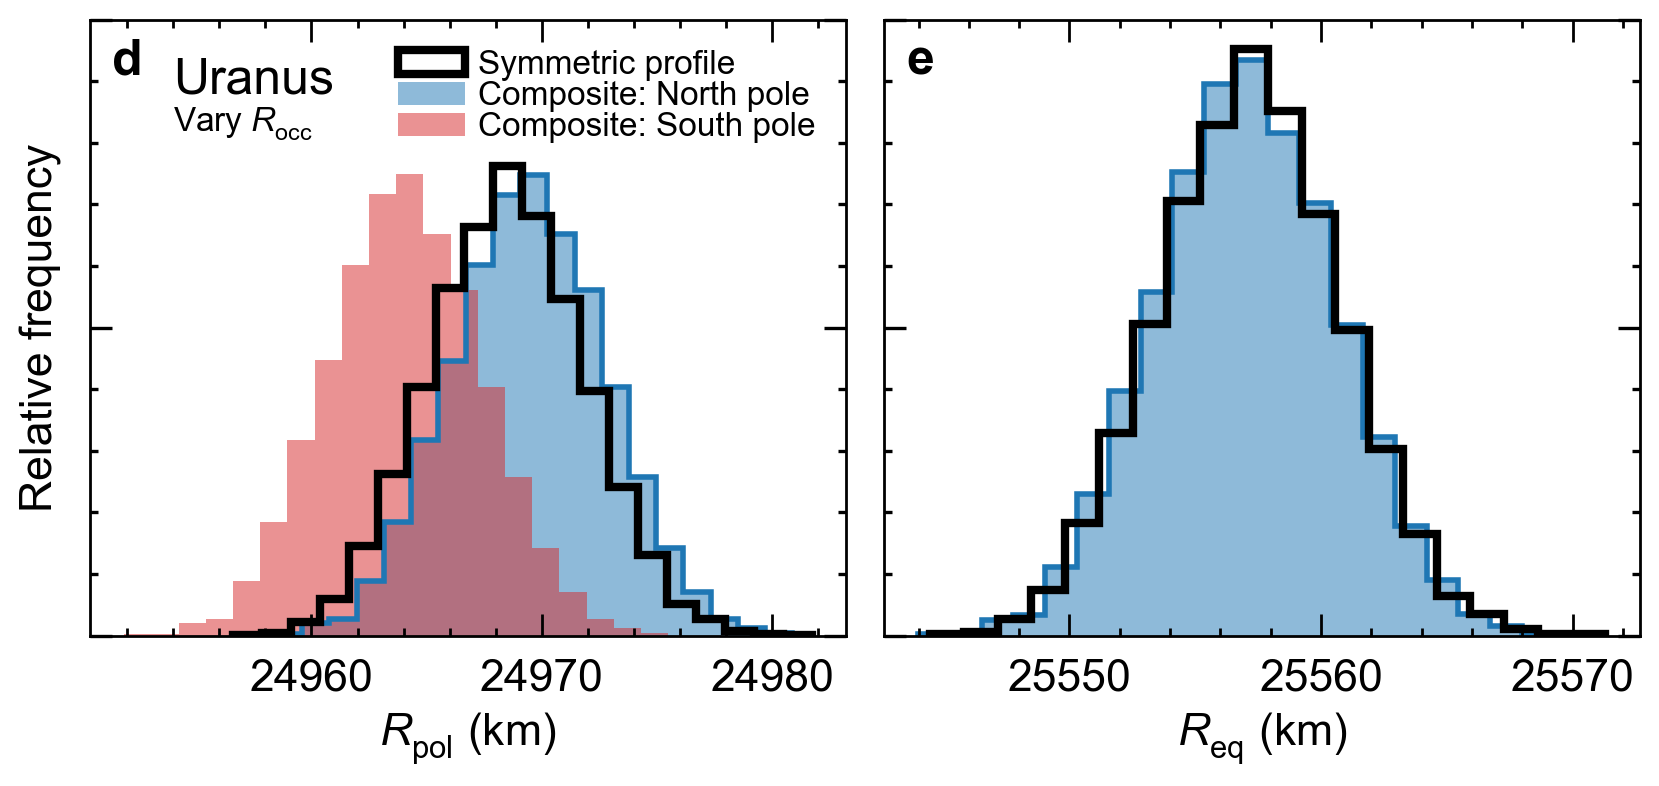

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'wspace':0.05})

rp = sampler_symmetric.get_chain()[nburn:, :, 0].flatten()

ax[0].hist(1e-5 * rp, density=True, color='k', histtype='step', lw=3, bins=20, label='Symmetric profile', zorder=5)
stats = rf'${np.mean(rp*1e-5):.1f}\pm{np.std(rp*1e-5):.1f}$ km'
print('pole:')
print('symmetric profile:', stats)
# plt.text(24975 - 0.1, 1.15, 'Symmetric\nprofile', ha='right', va='top', color='k')
# plt.text(24975 - 0.1, 1.02, stats, ha='right', va='top', color='k', fontsize=12)

rp_north = np.array([g.r[ 0] for g in sampler_composite.get_blobs()[nburn:, :].flatten()])
rp_south = np.array([g.r[-1] for g in sampler_composite.get_blobs()[nburn:, :].flatten()])
ax[0].hist(1e-5 * rp_north, density=True, color='tab:blue', histtype='stepfilled', alpha=0.5, bins=20, label='Composite: North pole')
ax[0].hist(1e-5 * rp_north, density=True, histtype='step', bins=20, edgecolor='tab:blue', lw=2)
ax[0].hist(1e-5 * rp_south, density=True, color='tab:red' , histtype='stepfilled', alpha=0.5, bins=20, label='Composite: South pole')
# ax[0].hist(1e-5 * rp_south, density=True, histtype='step', bins=20, edgecolor='tab:red', lw=3)
stats = rf'${np.mean(rp_north*1e-5):.1f}\pm{np.std(rp_north*1e-5):.1f}$ km'
print('composite profile, north pole:', stats)
stats = rf'${np.mean(rp_south*1e-5):.1f}\pm{np.std(rp_south*1e-5):.1f}$ km'
print('composite profile, south pole:', stats)
print()

print('equator:')
re = np.array([g.r[len(g.mu) // 2] for g in sampler_symmetric.get_blobs()[nburn:, :].flatten()])
ax[1].hist(1e-5 * re, density=True, color='k', histtype='step', lw=3, bins=20, label='Symmetric profile')
stats = rf'${np.mean(re*1e-5):.1f}\pm{np.std(re*1e-5):.1f}$ km'
print('symmetric profile:', stats)

re = np.array([g.r[len(g.mu) // 2] for g in sampler_composite.get_blobs()[nburn:, :].flatten()])
ax[1].hist(1e-5 * re, density=True, color='tab:blue', histtype='stepfilled', alpha=0.5, bins=20, label='Composite profile')
ax[1].hist(1e-5 * re, density=True, color='tab:blue', histtype='step', bins=20, lw=2, zorder=0)
stats = rf'${np.mean(re*1e-5):.1f}\pm{np.std(re*1e-5):.1f}$ km'
print('composite profile:', stats)


for iax, z in enumerate(ax):
    yl = np.array(z.get_ylim())
    if iax == 0: 
        yl *= 1.25
    z.set_yticks([0, yl[1] / 2, yl[1]], minor=False)
    z.set_yticks(np.linspace(0, yl[1], 11), minor=True)
    z.set_ylim(*yl)

ax[0].legend(fontsize=12, loc=1)

ax[0].set_xlabel(r'$R_{\rm pol}$ (km)')
ax[1].set_xlabel(r'$R_{\rm eq}$ (km)')
ax[0].set_ylabel(r'Relative frequency')
# plt.gca().yaxis.set_ticks([0, yl[1]/2, yl[1]], minor=False)
[z.tick_params(labelleft=False) for z in ax]
# ax[0].set_xlim(23800, 24500)
# ax[1].set_xlim(24730, 24800)
ax[0].text(0.11, 0.88, 'Uranus', fontsize=18, transform=ax[0].transAxes)
ax[0].text(0.11, 0.82, r'Vary $R_{\rm occ}$', fontsize=12, transform=ax[0].transAxes)
for iax, c in enumerate('de'):
    ax[iax].text(0.03, 0.97, c, weight='bold', fontsize=18, ha='left', va='top', transform=ax[iax].transAxes)

plt.savefig('figures/uranus_radii_vary_ro.pdf')

In [ ]:
''' save some output '''

if False: # save the emcee.EnsembleSampler objects as pickled python objects. 
    # for the several x10^4 models here this is ~10 GB. not very interoperable but possibly convenient in the short term.
    # do save these if you want to run the summary plots in plot_shape_uncertainties.ipynb.
    import dill as pickle
    with open('/tmp/uranus_sampler_symmetric.pkl', 'wb') as fw:
        pickle.dump(sampler_symmetric, fw)
    with open('/tmp/uranus_sampler_composite.pkl', 'wb') as fw:
        pickle.dump(sampler_composite, fw)
    # with open('/tmp/uranus_sampler_jn.pkl', 'wb') as fw:
    #     pickle.dump(sampler_jn, fw)
    with open('/tmp/uranus_sampler_wind.pkl', 'wb') as fw:
        pickle.dump(sampler_wind, fw)
elif True: # load pickles we've previously saved
    import dill as pickle
    with open('/tmp/uranus_sampler_symmetric.pkl', 'rb') as fr:
        sampler_symmetric = pickle.load(fr)
    with open('/tmp/uranus_sampler_composite.pkl', 'rb') as fr:
        sampler_composite = pickle.load(fr)
    with open('/tmp/uranus_sampler_wind.pkl', 'rb') as fr:
        sampler_wind = pickle.load(fr)

import pathlib
pathlib.Path('models/statistical_samples/uranus_symmetric' ).mkdir(exist_ok=True, parents=True)
pathlib.Path('models/statistical_samples/uranus_composite' ).mkdir(exist_ok=True, parents=True)
pathlib.Path('models/statistical_samples/uranus_vary_wind' ).mkdir(exist_ok=True, parents=True)
pathlib.Path('models/statistical_samples/uranus_vary_jn'   ).mkdir(exist_ok=True, parents=True)

# save mcmc chains to plaintext, including log posterior probability and equatorial and polar radii.

outfile = 'models/statistical_samples/uranus_symmetric_chain.txt'
blobs = sampler_symmetric.get_blobs().flatten()
index = np.array([i for i, g in enumerate(blobs)])
rp_km = np.array([1e-5 * g.r[ 0] for g in blobs])
re_km = np.array([1e-5 * g.r[len(g.mu) // 2] for g in blobs])
lnp = sampler_symmetric.get_log_prob().flatten()
header  = "polar and equatorial radii for Uranus's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
header += 'the models summarized in this file assume the symmetric wind profile from Sromovsky et al. (2015, Icarus 258) Equation 2.\n'
header += 'the distribution of models in this file comes from Markov chain Monte Carlo fits to the pair of Voyager 2 radio occultations reported in Lindal et al. 1987.\n'
header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16} {'lnp':>16} "
fmt = ('%5i', '%16.3f', '%16.3f', '%16.3e')
np.savetxt(outfile, np.array([index, rp_km, re_km, lnp]).T, fmt=fmt, header=header, comments='')

outfile = 'models/statistical_samples/uranus_composite_chain.txt'
blobs = sampler_composite.get_blobs().flatten()
index = np.array([i for i, g in enumerate(blobs)])
rn_km = np.array([1e-5 * g.r[ 0] for g in blobs])
rs_km = np.array([1e-5 * g.r[-1] for g in blobs])
re_km = np.array([1e-5 * g.r[len(g.mu) // 2] for g in blobs])
lnp = sampler_composite.get_log_prob().flatten()
header  = "polar and equatorial radii for Uranus's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
header += 'the models summarized in this file assume the composite asymmetric wind profile from Sromovsky et al. (2015, Icarus 258) Section 4.5 and Table 6.\n'
header += 'the distribution of models in this file comes from Markov chain Monte Carlo fits to the pair of Voyager 2 radio occultations reported in Lindal et al. 1987.\n'
header += f"{'index':>5} {'r_pol_north_km':>16} {'r_pol_south_km':>16} {'r_eq_km':>16} {'lnp':>16}"
fmt = ('%5i', '%16.3f', '%16.3f', '%16.3f', '%16.3e')
np.savetxt(outfile, np.array([index, rn_km, rs_km, re_km, lnp]).T, fmt=fmt, header=header, comments='')

outfile = 'models/statistical_samples/uranus_vary_jn.txt'
# blobs = sampler_jn.get_blobs().flatten()
# index = np.array([i for i, g in enumerate(blobs)])
# rp_km = np.array([1e-5 * g.r[ 0] for g in blobs])
# re_km = np.array([1e-5 * g.r[len(g.mu) // 2] for g in blobs])
# lnp = sampler_jn.get_log_prob().flatten()
# j2 = sampler_jn.get_chain()[:, :, 0].flatten()
# j4 = sampler_jn.get_chain()[:, :, 1].flatten()
index = np.arange(len(results_sample_jn['rp']))
rp_km = 1e-5 * results_sample_jn['rp']
re_km = 1e-5 * results_sample_jn['re']
j2 = results_sample_jn['j2']
j4 = results_sample_jn['j4']
j6 = results_sample_jn['j6']
header  = "polar and equatorial radii for Uranus's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
header += 'the models summarized in this file assume the symmetric wind profile from Sromovsky et al. (2015, Icarus 258) Equation 2.\n'
header += 'the polar and equatorial radii in this file come from random draws in j2 and j4 from the French et al. (2024, Icarus 411) error ellipsoid,\n'
header += 'followed by direct integration of Equation (3) from one of the Voyager 2 radio points reported in Lindal et al. 1987 to either the equator or the pole.\n'
header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16} {'j2':>16} {'j4':>16} {'j6':>16}"
fmt = ('%5i', '%16.5f', '%16.5f', '%16.8e', '%16.8e', '%16.8e')
np.savetxt(outfile, np.array([index, rp_km, re_km, j2, j4, j6]).T, fmt=fmt, header=header, comments='')

outfile = 'models/statistical_samples/uranus_vary_wind_chain.txt'
blobs = sampler_wind.get_blobs().flatten()
index = np.array([i for i, g in enumerate(blobs)])
rp_km = np.array([1e-5 * g.r[ 0] for g in blobs])
re_km = np.array([1e-5 * g.r[len(g.mu) // 2] for g in blobs])
lnp = sampler_wind.get_log_prob().flatten()
cn = np.array([sampler_wind.get_chain()[:, :, idim].flatten() for idim in 1 + np.arange(10)])
header  = "polar and equatorial radii for Uranus's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
header += 'the models summarized in this file assume the symmetric wind profile from Sromovsky et al. (2015, Icarus 258) Equation 2.\n'
header += 'the distribution of models in this file comes from Markov chain Monte Carlo fits to the pair of Voyager 2 radio occultations reported in Lindal et al. 1987.\n'
header += 'these solutions vary the polar radius to fit the pair of Voyager 2 occultations reported in Lindal et al. 1987 to a Gaussian standard deviation of 50 m.\n'
header += 'j2 and j4 are also allowed to vary within their Gaussian error ellipse following French et al. (2024, Icarus 411).\n'
header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16} {'c0':>16} {'c2':>16} {'c4':>16} {'c6':>16} {'c8':>16} {'c10':>16} {'c12':>16} {'c14':>16} {'c16':>16} {'c18':>16} {'lnp':>16} "
fmt = ('%5i', '%16.3f', '%16.3f', '%16.6f', '%16.6f', '%16.6f', '%16.6f', '%16.6f', '%16.6f', '%16.6f', '%16.6f', '%16.6f', '%16.6f', '%16.3e')
np.savetxt(outfile, np.array([index, rp_km, re_km, *cn, lnp]).T, fmt=fmt, header=header, comments='')
# could save as compressed numpy array; opting for plaintext for interoperability. will gzip this ~50 MB text file for the repository.
# np.savez_compressed(outfile, header=header, index=index, r_pol_km=rp_km, r_eq_km=re_km, cn=cn, lnp=lnp, allow_pickle=False)

# detailed model output saved to plaintext for a small number of models
n_models_each_type = 32
for i in np.arange(n_models_each_type):
    g = sampler_symmetric.get_blobs().flatten()[-i] # count back from the end
    outfile = f'models/statistical_samples/uranus_symmetric/uranus_symmetric_{i:02}.txt'
    header  = "shape model output for Uranus's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
    header += 'this model assumes the symmetric wind profile from Sromovsky et al. (2015, Icarus 258) Equation 2.\n'
    header += 'these solutions vary the polar radius to fit the pair of Voyager 2 occultations reported in Lindal et al. 1987 to a Gaussian standard deviation of 5 km.\n'
    header += 'mu=sin(phi), phi [radians], and lat_deg [degrees] refer to planetocentric latitude; lat_pg_deg gives planetographic latitude in degrees.\n'
    # header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16}"
    fmt = '%16.10f'
    names = 'mu', 'phi_rad', 'lat_deg', 'lat_pg_deg', 'psi_rad', 'omega_rad_s-1', 'r_km'
    for name in names:
        header += f"{name:>16} "
    data = np.array([g.mu, g.phi, g.lat, g.planetographic_latitude, g.psi, g.omega, 1e-5 * g.r]).T
    np.savetxt(outfile, data, fmt=fmt, header=header, comments='')

    g = sampler_composite.get_blobs().flatten()[-i]
    outfile = f'models/statistical_samples/uranus_composite/uranus_composite_{i:02}.txt'
    header  = "shape model output for Uranus's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
    header += 'this model assumes the composite asymmetric wind profile described in Sromovsky et al. (2015, Icarus 258) Section 4.5 and Table 6.\n'
    header += 'these solutions vary the (north) polar radius to fit the pair of Voyager 2 occultations reported in Lindal et al. 1987 to a Gaussian standard deviation of 5 km.\n'
    header += 'mu=sin(phi), phi [radians], and lat_deg [degrees] refer to planetocentric latitude; lat_pg_deg gives planetographic latitude in degrees.\n'
    # header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16}"
    fmt = '%16.10f'
    names = 'mu', 'phi_rad', 'lat_deg', 'lat_pg_deg', 'psi_rad', 'omega_rad_s-1', 'r_km'
    for name in names:
        header += f"{name:>16} "
    data = np.array([g.mu, g.phi, g.lat, g.planetographic_latitude, g.psi, g.omega, 1e-5 * g.r]).T
    np.savetxt(outfile, data, fmt=fmt, header=header, comments='')

    g = sampler_wind.get_blobs().flatten()[-i]
    outfile = f'models/statistical_samples/uranus_vary_wind/uranus_vary_wind_{i:02}.txt'
    header  = "shape model output for Uranus's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
    header += 'this model assumes the symmetric wind profile from Sromovsky et al. (2015, Icarus 258) Equation (2).\n'
    header += 'these solutions vary the polar radius to fit the pair of Voyager 2 occultations reported in Lindal et al. 1987 to a Gaussian standard deviation of 50 m.\n'
    header += 'the wind fit spectral coefficients are also allowed to vary within their Gaussian uncertainties following S15 Table 5 (Fit 1).\n'
    header += f'this model has l=0,2,..., 18 wind spectral cofficients: '
    for n in range(10):
        header += f'{sampler_wind.get_chain()[:, :, 1 + n].flatten()[-i]:10.6f}'
    header += '\n'
    header += 'mu=sin(phi), phi [radians], and lat_deg [degrees] refer to planetocentric latitude; lat_pg_deg gives planetographic latitude in degrees.\n'
    # header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16}"
    fmt = '%16.10f'
    names = 'mu', 'phi_rad', 'lat_deg', 'lat_pg_deg', 'psi_rad', 'omega_rad_s-1', 'r_km'
    for name in names:
        header += f"{name:>16} "
    data = np.array([g.mu, g.phi, g.lat, g.planetographic_latitude, g.psi, g.omega, 1e-5 * g.r]).T
    np.savetxt(outfile, data, fmt=fmt, header=header, comments='')
